# Multi-basin LSTM analysis

In [61]:
from torch.utils.data import ConcatDataset
import glob
import xarray as xr

basin_files = glob.glob("Caravan-nc/timeseries/netcdf/camels/*.nc")

In [62]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size, # the dimensionality of ct and ht
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.output = nn.Linear(hidden_size, output_size) # This is the fully connected output layer turning the h_t into an output

    def forward(self, x, state=None): # This is what happens when you call model(x); state=None means if there is no supplied LSTM state then start from scratch
        '''
        x is in Batch, Time, input size dimensions
        '''
        out, (h_n, c_n) = self.lstm(x, state)       # out is in Batch, Time, hidden_size dimensions
        y = self.output(out[:, -1, :])                  # last time step yields B, hidden which transforms into Batch, output size
        return y, (h_n, c_n)


# PyTorch dataloader needs data to be able to do certain things
from torch.utils.data import Dataset, DataLoader

class BasinDataset(Dataset):
    def __init__(self, features, streamflows, water_years, 
                 dates, seq_len=365):
        '''
        features in time, num_features dimensional numpy array
        streamflow in time dimensional numpy array
        '''
        self.x = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(streamflows, dtype=torch.float32)
        self.seq_len = seq_len
        self.water_years = water_years
        self.date = dates.astype('datetime64[D]').astype(np.int64) # Pytorch cannot datetime64 format
        # convert back later using np.array(t_batch, dtype='datetime64[D]')


    def __len__(self): # this is one of those things dataloader needs from a dataset
        return len(self.y) - self.seq_len # There are total - 365 sequences available

    def __getitem__(self, i):
        x_seq = self.x[i : i + self.seq_len]
        y_val = self.y[i + self.seq_len]
        t_val = self.date[i + self.seq_len]
        water_year_val = self.water_years[i + self.seq_len]
        return x_seq, y_val, t_val, water_year_val

# Define the normalised square loss for the training
def nse_loss(y_pred, y_obs, std_train):
    return torch.mean((y_pred - y_obs) ** 2) / (std_train + 1e-6) ** 2

In [63]:
import numpy as np
from scipy.stats import pearson3

def calc_return_periods(ds):
    '''
    Takes in nc ds and treats it using B17b return period fitting 
    Returns dict (water_year, return period of max streamflow event that year)
    '''
    annual_max = ds['streamflow'].groupby('water_year').max('date')
    log_annual_max = np.log10(annual_max) # For the B17b fitting procedure

    params = pearson3.fit(log_annual_max)
    skew, mu, sig = params # shape location scale of the fit

    # Calculate the return years by evaluating the fit PDF distribution
    p3cdf = pearson3.cdf(log_annual_max, skew, loc=mu, scale=sig)
    return_periods_list = 1/(1-p3cdf)

    # I want these to live in a dictionary
    return_periods = dict(zip(annual_max['water_year'].values, return_periods_list))

    return return_periods

def add_water_year(ds):
    '''
    Water year is defined as Oct 1 to  Sep 30.
    Oct, Nov, Dec are labelled as regular year + 1
    '''
    t = ds['date']
    water_year = t.dt.year + (t.dt.month >= 10)
    new_ds = ds.assign_coords(water_year=water_year)
    return new_ds

In [64]:
from torch.utils.data import ConcatDataset

trainsets = []
validsets = []
testsets = [] # test_sets and return period dicts have the same indexing
return_period_dicts = []
testdss = []

last_train_year = 1999
last_valid_year = 2004

for basin_file in basin_files:
    ds = xr.open_dataset(basin_file)

    # Get rid of NaN values
    ds = ds.dropna(dim='date', 
               subset=['streamflow', 
                       'total_precipitation_sum',
                       'temperature_2m_mean',
                       'surface_net_solar_radiation_mean',
                       'surface_net_thermal_radiation_mean',
                       'dewpoint_temperature_2m_mean',
                       'u_component_of_wind_10m_mean',
                       'v_component_of_wind_10m_mean'], # From which features
                 how='any') # Any of the subsets

    # Water year
    ds = add_water_year(ds)

    # Calc return periods and add return period dict to list
    return_period_dict = calc_return_periods(ds)
    return_period_dicts.append(return_period_dict)

    # Split indices for this dataset
    all_water_years = np.array(ds['water_year'])
    trainsplit_idx = np.searchsorted(all_water_years, last_train_year + 1e-4)
    validsplit_idx = np.searchsorted(all_water_years, last_valid_year + 1e-4) # split idx is the first datapoint of the test set

    # Create the features
    features = np.stack([
    ds['total_precipitation_sum'].values,
    ds['temperature_2m_mean'].values,
    ds['surface_net_solar_radiation_mean'].values,
    ds['surface_net_thermal_radiation_mean'].values,
    ds['dewpoint_temperature_2m_mean'].values,
    np.sqrt(ds['u_component_of_wind_10m_mean']**2 + ds['v_component_of_wind_10m_mean']**2).values,
    ], axis=1)

    # Do the splitting of each bit
    x_train = features[:trainsplit_idx]
    x_valid = features[trainsplit_idx:validsplit_idx]
    x_test = features[validsplit_idx:]

    y_train = ds['streamflow'].values[:trainsplit_idx]
    y_valid = ds['streamflow'].values[trainsplit_idx:validsplit_idx]
    y_test = ds['streamflow'].values[validsplit_idx:]

    water_year_train = ds['water_year'].values[:trainsplit_idx]
    water_year_valid = ds['water_year'].values[trainsplit_idx:validsplit_idx]
    water_year_test = ds['water_year'].values[validsplit_idx:]

    t_train = ds['date'].values[:trainsplit_idx]
    t_valid = ds['date'].values[trainsplit_idx:validsplit_idx]
    t_test = ds['date'].values[validsplit_idx:]

    # Create the dataset objects
    trainset = BasinDataset(features=x_train,
                                       streamflows=y_train,
                                       water_years=water_year_train,
                                       dates=t_train)
    validset = BasinDataset(features=x_valid,
                                       streamflows=y_valid,
                                       water_years=water_year_valid,
                                       dates=t_valid)
    testset = BasinDataset(features=x_test, 
                                     streamflows=y_test,
                                     water_years=water_year_test,
                                     dates=t_test)

    # Append these to the relevant places
    trainsets.append(trainset)
    validsets.append(validset)
    testsets.append(testset)

    testdss.append(ds.isel(date=slice(validsplit_idx, None)))

# Put them into dataloaders
train_loader = DataLoader(
    ConcatDataset(trainsets),
    batch_size=256,
    shuffle=True
)

valid_loader = DataLoader(
    ConcatDataset(validsets),
    batch_size=256,
    shuffle=False
)

c:\Users\Joey\Desktop\PhD_Applications\Recreating Frame Paper\venvFrame\Lib\site-packages\xarray\computation\apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


ValueError: The data contains non-finite values.

In [ ]:
std_train = np.std(y_train)

num_features = x_train.shape[1]
model = LSTMModel(input_size=num_features, 
                hidden_size=128,
                num_layers=1,
                output_size=1, # only the streamflow is predicted
                )
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

best_valid_loss = float('inf')
patience = 5
epochs_no_improve = 0

train_loss_history = []
valid_loss_history = []

for epoch in range(30):
    model.train()
    for x_batch, y_batch, t_batch, _ in train_loader:
        optimiser.zero_grad()
        y_pred, (h_n, c_n) = model(x_batch)
        loss = nse_loss(y_pred.squeeze(), y_batch, std_train=std_train)
        train_loss_history.append(loss.item())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # paper clips to norm 1
        optimiser.step()

        # Evaluate on validation set
        model.eval()
        valid_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch, t_batch, _ in valid_loader:
                y_pred, _ = model(x_batch)
                valid_loss += nse_loss(y_pred.squeeze(), y_batch, std_train=std_train).item()
        valid_loss /= len(valid_loader)
        valid_loss_history.append(valid_loss)
    print(f"{epoch}/30  valid_loss={valid_loss:.4f}")
    

    # Early stopping
    if valid_loss <= best_valid_loss:
        best_valid_loss = valid_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model2.pt")

    else: 
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Stopping early")
            break


0/30  valid_loss=0.1756


KeyboardInterrupt: 

In [ ]:
# Restore model
model.load_state_dict(torch.load("best_model2.pt"))

<All keys matched successfully>

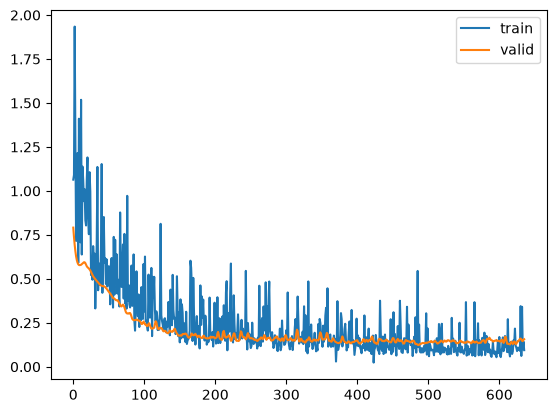

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_loss_history, label = 'train')
plt.plot(valid_loss_history, label = 'valid')
plt.legend()
plt.show()

In [ ]:
boundaries = np.array([5, 25, 50, 100, np.inf])
error_peak_Q_binned = [[],[],[],[],[]]

for testset, return_period_dict, test_ds in zip(testsets, return_period_dicts, testdss):

    pred_water_years = []
    pred_dates = []
    pred_streamflows = []

    test_loader = DataLoader(
    testset,
    batch_size=256,
    shuffle=False
    )

    # Test loss
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch, t_batch, water_year_batch in test_loader:
            y_pred, _ = model(x_batch)
            test_loss += nse_loss(y_pred.squeeze(), y_batch, std_train).item()
            pred_water_years.append(water_year_batch)
            pred_dates.append(t_batch)
            pred_streamflows.append(y_pred.squeeze())
        test_loss /= len(test_loader)
    # print(f"Test loss NSE: {test_loss}")

    # Concatenate into (water_year, date, streamflow)
    pred_water_years = np.concatenate(pred_water_years)
    pred_dates = np.concatenate(pred_dates)
    pred_streamflows = np.concatenate(pred_streamflows)

    # Turn it back into an xarray
    pred_ds = xr.Dataset(
        {
            "streamflow": ("date", pred_streamflows),
        },
        coords={"date": pred_dates.astype("datetime64[D]"),
                "water_year": ("date", pred_water_years),
                }
    )

    # Now now get the annual max from the observed and predicted
    all_obs_annual_maxdate = test_ds['streamflow'].groupby('water_year').map(lambda x: x.idxmax('date')) # map applies to each group
    obs_annual_maxdate = all_obs_annual_maxdate.sel(water_year=slice(last_valid_year+2, None)) # These are the highest streamflow dates for the observed

    pred_annual_maxdate = pred_ds['streamflow'].groupby('water_year').map(lambda x: x.idxmax('date'))
    # print(pred_annual_maxdate)
    # print(obs_annual_maxdate)

    date_delta = (obs_annual_maxdate.values - pred_annual_maxdate.values)/86400000000000
    # print(date_delta)

    Q_obs = test_ds['streamflow'].sel(date=pred_annual_maxdate) # The flows observed on the predicted maxdays
    Q_sim =  pred_ds['streamflow'].sel(date=pred_annual_maxdate)

    error_peak_Qs = np.abs(Q_obs - Q_sim)/Q_obs

    # Bin the error_peak_Q
    # errors to bin are in error_peak_Q
    # their concomitant water_years can be extracted by error_peak_Q['water_year']
    error_water_years = error_peak_Qs['water_year'].values

    # use this to extract the return years above
    error_return_periods = [return_period_dict[key] for key in error_water_years]

    # Now compare these to the boundaries using bisect right or searchsorted
    error_bin_idxs = np.searchsorted(boundaries + 1e-3, error_return_periods, side='left')

    # Now place the errors into those bins
    for bin_idx, error_peak_Q in zip(error_bin_idxs, error_peak_Qs):
        error_peak_Q_binned[bin_idx].append(error_peak_Q.values)


In [ ]:
error_peak_Q_binned

[[array(0.5264455, dtype=float32),
  array(0.05647391, dtype=float32),
  array(0.013955, dtype=float32),
  array(0.01808066, dtype=float32),
  array(0.3567287, dtype=float32),
  array(0.78943485, dtype=float32),
  array(0.03185101, dtype=float32),
  array(0.89619243, dtype=float32),
  array(0.50153875, dtype=float32),
  array(0.44281337, dtype=float32),
  array(0.5536929, dtype=float32),
  array(0.5174731, dtype=float32),
  array(0.16136408, dtype=float32)],
 [array(0.04317307, dtype=float32),
  array(0.3585604, dtype=float32),
  array(0.6214271, dtype=float32),
  array(0.6201566, dtype=float32)],
 [],
 [],
 [array(0.47501147, dtype=float32)]]

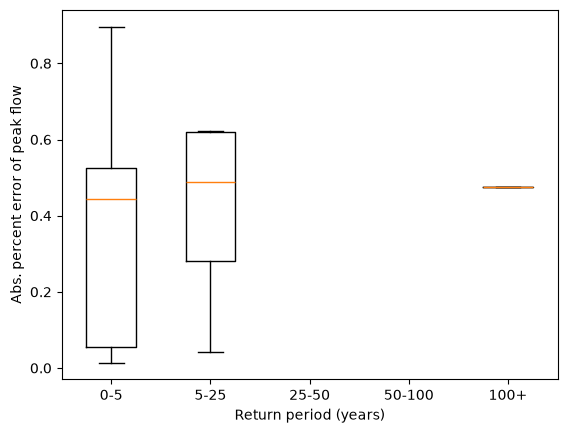

In [ ]:
plt.boxplot(error_peak_Q_binned, tick_labels=['0-5', '5-25', '25-50','50-100','100+'])
plt.ylabel('Abs. percent error of peak flow')
plt.xlabel('Return period (years)')
plt.show()